## **AdaBoost Classifier**

## Import Libraries

In [ ]:
# ==========================================================
# Import Libraries
# ==========================================================

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
    
)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [20]:
df = pd.read_csv('main_clean_data.csv')

In [21]:
df.head()

,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,...,education_background_Undergrad,education_background_WorkingPro,course_level_Advanced,course_level_Beginner,course_level_Intermediate,course_category_Business,course_category_Data,course_category_Design,course_category_Marketing,course_category_Programming
0,1.395524,-0.975477,-1.886282,-1.062757,-1.540257,-0.369750,-1.458420,-0.344933,-1.018644,-1.743625,...,1,0,0,0,1,1,0,0,0,0
1,-1.314686,0.493337,-0.213248,1.101746,-1.201238,-1.159715,1.706847,-0.344933,-1.153411,1.423907,...,1,0,0,0,1,0,0,0,0,1
2,0.130760,0.827158,-1.328604,-1.117974,-0.523201,-1.949681,-0.930876,-1.357553,-0.352295,-0.320531,...,0,0,1,0,0,0,0,0,0,1
3,0.311440,-1.109006,1.794392,0.538533,2.256752,0.815198,1.179302,-1.357553,-0.569420,0.276250,...,1,0,0,1,0,0,0,1,0,0
4,0.311440,-0.975477,0.455965,1.664958,1.171892,0.815198,-0.930876,-1.357553,-0.135170,-0.283806,...,0,1,1,0,0,1,0,0,0,0


# Features and Target


In [22]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop('completion_status', axis=1)

y = df['completion_status']

## Feature and Target Selection

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# AdaBoost Classifier


In [24]:
# ==========================================================
# AdaBoost Classifier
# ==========================================================

ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_clf.fit(X_train,y_train)

y_pred = ada_clf.predict(X_test)

acc = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :",acc)

Accuracy : 0.8335233751425314


## Classification Report

In [25]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.88      0.86      0.87       564
         1.0       0.76      0.79      0.77       313

    accuracy                           0.83       877
   macro avg       0.82      0.82      0.82       877
weighted avg       0.84      0.83      0.83       877



## Confusion Matrix

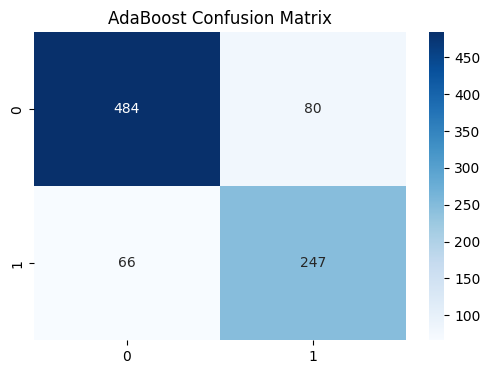

In [26]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "AdaBoost Confusion Matrix"
)

plt.show()

# ROC AUC Score


In [27]:
# ==========================================================
# ROC AUC Score
# ==========================================================

from sklearn.metrics import roc_auc_score

# Probability for Positive Class
y_prob = ada_clf.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC Score :{auc_score:.4f}")

ROC-AUC Score :0.9133


# ROC Curve


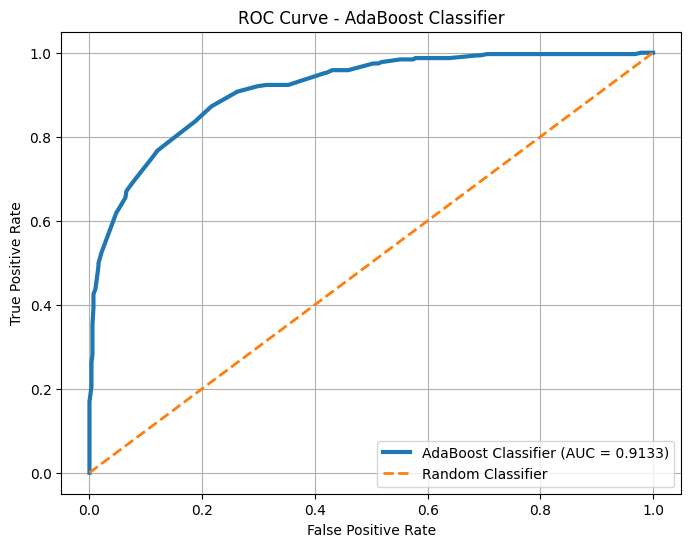

In [28]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'AdaBoost Classifier (AUC = {auc_score:.4f})'
)

# Random Classifier Line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2,
    label='Random Classifier'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - AdaBoost Classifier"
)

plt.legend()

plt.grid(True)

plt.show()

## **AdaBoost Regressor**

## Import Libraries

In [12]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Features and Target


In [13]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop(
    'final_score',
    axis=1
)

y = df['final_score']

## Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [15]:
ada_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_reg.fit(
    X_train,
    y_train
)

y_pred = ada_reg.predict(
    X_test
)

## Regression Metrics

In [16]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 6.549795512124019
MSE : 66.13471140811923
RMSE : 8.1323250923779
R2 : 0.6155494502908399


# Actual vs Predicted


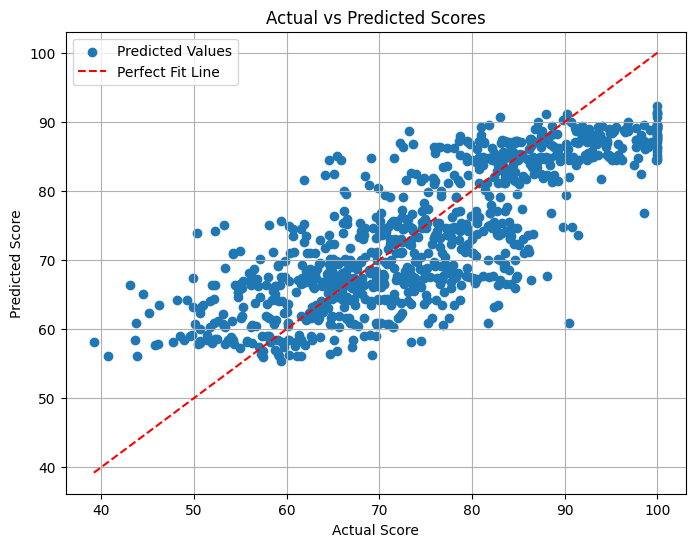

In [17]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    label="Predicted Values"
)

# Perfect Fit Line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)

plt.xlabel("Actual Score")

plt.ylabel("Predicted Score")

plt.title("Actual vs Predicted Scores")

plt.legend()

plt.grid(True)

plt.show()

# AdaBoost Classifier Analysis

## Overview

AdaBoost (Adaptive Boosting) is an ensemble learning algorithm that combines multiple weak learners to create a stronger predictive model. It works by sequentially training weak classifiers and assigning higher importance to previously misclassified observations.

In this project, AdaBoost Classifier was implemented to predict student course completion status.

---

## Classification Results

### Accuracy Score

**Accuracy = 83.35%**

This indicates that the AdaBoost Classifier correctly predicted approximately 83 out of every 100 student completion outcomes.

---

### Classification Report

| Class | Precision | Recall | F1-Score |
|---------|---------|---------|---------|
| 0 (Not Completed) | 0.88 | 0.86 | 0.87 |
| 1 (Completed) | 0.76 | 0.79 | 0.77 |

#### Macro Average

- Precision: 0.82
- Recall: 0.82
- F1-Score: 0.82

#### Weighted Average

- Precision: 0.84
- Recall: 0.83
- F1-Score: 0.83

---

### Interpretation

- The model performed exceptionally well for predicting students who did not complete the course.
- Recall of 79% for the completed class indicates that most successful students were correctly identified.
- The F1-score values demonstrate a good balance between precision and recall.
- Overall classification performance is stable and reliable.

---

## ROC-AUC Analysis

### ROC-AUC Score

**ROC-AUC = 0.9133**

The Receiver Operating Characteristic Area Under Curve (ROC-AUC) measures the model's ability to distinguish between completed and non-completed students.

### Interpretation

| AUC Score | Performance |
|------------|------------|
| 0.50 | Poor |
| 0.60 - 0.70 | Fair |
| 0.70 - 0.80 | Good |
| 0.80 - 0.90 | Very Good |
| Above 0.90 | Excellent |

The obtained ROC-AUC score of **0.9133** indicates excellent classification capability and strong class separation performance.

---

## AdaBoost Classifier Conclusion

The AdaBoost Classifier achieved an accuracy of **83.35%** and an excellent ROC-AUC score of **0.9133**. The model demonstrated strong classification performance by effectively distinguishing between students who completed the course and those who did not. The high ROC-AUC score indicates excellent discriminative power, making AdaBoost a reliable classification model for educational outcome prediction.

---

# AdaBoost Regressor Analysis

## Overview

AdaBoost Regressor extends the AdaBoost concept to regression problems by sequentially training weak regression models and focusing on observations with larger prediction errors.

The objective was to predict student final scores based on academic and engagement-related features.

---

## Regression Results

| Metric | Value |
|----------|----------|
| MAE | 6.55 |
| MSE | 66.13 |
| RMSE | 8.13 |
| R² Score | 0.6155 |

---

### Mean Absolute Error (MAE)

**MAE = 6.55**

On average, the predicted score differs from the actual score by approximately 6.55 marks.

---

### Mean Squared Error (MSE)

**MSE = 66.13**

The average squared prediction error is relatively low, indicating reasonable prediction accuracy.

---

### Root Mean Squared Error (RMSE)

**RMSE = 8.13**

The model's predictions deviate from actual scores by approximately 8.13 marks on average.

---

### R² Score

**R² Score = 0.6155**

This indicates that approximately **61.55% of the variation in student final scores** is explained by the AdaBoost Regressor model.

---

## Interpretation

- The model successfully captures a significant portion of the relationship between input features and final scores.
- The R² score above 0.60 indicates moderate to strong predictive capability.
- Error values remain within an acceptable range for educational performance prediction.
- The model demonstrates good generalization ability and can be used for score prediction tasks.

---

## AdaBoost Regressor Conclusion

The AdaBoost Regressor achieved an R² score of **0.6155**, indicating that the model explains over 61% of the variance in student final scores. With an MAE of **6.55** and RMSE of **8.13**, the model produced reasonably accurate score predictions. Overall, AdaBoost Regressor proved effective for predicting student performance and serves as a strong baseline regression model for educational analytics.

---

# Final AdaBoost Summary

AdaBoost successfully improved predictive performance through sequential learning of weak learners. The classifier achieved **83.35% accuracy** with an excellent **ROC-AUC score of 0.9133**, demonstrating strong classification capability. The regressor achieved an **R² score of 0.6155**, providing reliable final score predictions. These results confirm that AdaBoost is an effective ensemble learning technique for both classification and regression tasks in the Smart Outcome Predictor project.